# Big Sur Marathon — Parametric Distribution Fitting for Simio

This notebook is a generalization of `Ketner_Fit_Analysis.ipynb`. It cleans the
scraped Big Sur Marathon results, fits a parametric distribution to the finish
times, and **emits the Simio `Random.*` expression you can paste directly into
a Simio model**.

Improvements over the original:

1. **Works on the marathon CSVs** — handles `HH:MM:SS` strings, DNS/DNF/DQ rows,
   and missing values.
2. **Distribution-agnostic goodness-of-fit framework** — the `gof_tests()`
   function takes *any* SciPy continuous distribution name and runs KS,
   Anderson–Darling, and Chi-square. (The original hard-coded the Normal in
   the AD and Chi-square cells.)
3. **Simio expression generator** — the `to_simio()` registry maps SciPy
   parameters to the exact `Random.*` syntax Simio expects, including the
   parameter-order and parameterization quirks (Weibull's scale-first order,
   Lognormal's mean/std-of-the-lognormal convention, Beta's [0, 1] support,
   Erlang's `mean = k * scale`).

> Marathon times are reported in **minutes** throughout. Adjust `TIME_UNIT`
> if you'd rather work in seconds or hours.

## Step 0 — Setup

In [1]:
# !pip install fitter numpy pandas scipy matplotlib

In [2]:
import re
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from fitter import Fitter
import warnings
warnings.filterwarnings("ignore")

np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

### Configuration

Change the values in this cell to fit a different slice of the data
(e.g. a single year, only female runners, only the 30–39 age bracket).

In [12]:
DATA_PATH    = "big_sur_all_years.csv"    # combined file is the default; or use big_sur_2024.csv etc.
TIME_COLUMN  = "Chip Elapsed"             # 'Chip Elapsed' (preferred) or 'Gun Elapsed'
TIME_UNIT    = "minutes"                  # 'minutes' | 'seconds' | 'hours'

# Filters (set any to None to disable)
YEAR_FILTER   = None        # e.g. 2024  or  None for all years pooled
GENDER_FILTER = None        # 'M', 'F', or None
AGE_RANGE     = None        # e.g. (30, 39) or None

# Distribution-fitting candidates (any continuous scipy.stats name is allowed)
CANDIDATE_DISTRIBUTIONS = [
    "norm", "lognorm", "gamma", "weibull_min",
    "beta", "expon", "triang", "uniform", "erlang",
]

RANDOM_STATE = 42

## Step 1 — Load and clean

The scraped CSVs contain three things that have to be handled before fitting:

| Issue | Fix |
|---|---|
| Time strings like `"03:42:18"` | Parse to a numeric duration. |
| `DNS`, `DNF`, `DQ` rows | Drop — they're not finish times. |
| `Age == 0` placeholder rows | Drop. |

In [13]:
def hms_to_seconds(s):
    """Parse 'HH:MM:SS', 'H:MM:SS', or 'MM:SS' to seconds. Returns NaN on failure."""
    if not isinstance(s, str):
        return np.nan
    s = s.strip()
    if not s or not re.match(r"^\d{1,2}:\d{2}(:\d{2})?(\.\d+)?$", s):
        return np.nan
    parts = s.split(":")
    try:
        if len(parts) == 3:
            h, m, sec = parts
            return int(h) * 3600 + int(m) * 60 + float(sec)
        if len(parts) == 2:
            m, sec = parts
            return int(m) * 60 + float(sec)
    except (ValueError, TypeError):
        return np.nan
    return np.nan


def to_unit(seconds, unit):
    if unit == "seconds": return seconds
    if unit == "minutes": return seconds / 60.0
    if unit == "hours":   return seconds / 3600.0
    raise ValueError(f"Unknown TIME_UNIT: {unit!r}")

In [14]:
df = pd.read_csv(DATA_PATH)
print(f"Raw rows: {len(df):,}")

# Drop non-finishers (DNS, DNF, DQ)
non_finish = {"DNS", "DNF", "DQ"}
df = df[~df[TIME_COLUMN].astype(str).str.upper().isin(non_finish)].copy()
print(f"After dropping DNS/DNF/DQ: {len(df):,}")

# Parse time
df["TimeSec"] = df[TIME_COLUMN].apply(hms_to_seconds)
df = df.dropna(subset=["TimeSec"])
df = df[df["TimeSec"] > 0]
print(f"After parsing & dropping invalid times: {len(df):,}")

# Age sanity
df = df[df["Age"] > 0]
print(f"After dropping age=0 placeholders: {len(df):,}")

df["Time"] = to_unit(df["TimeSec"], TIME_UNIT)
df.head()

Raw rows: 25,125
After dropping DNS/DNF/DQ: 25,089
After parsing & dropping invalid times: 23,634
After dropping age=0 placeholders: 23,631


,Bib,Name,Team Name,City,Gun Elapsed,Chip Elapsed,Pace,Event,Event Place,Age,Age Place,Gender,Gender Place,year,TimeSec,Time
0,3257,ADAM ROACH,NaN,PEBBLE BEACH,02:29:26,02:29:25,05:42 min/mile,MARATHON,1,34,1,M,1,2018,"8,965.0000",149.4167
1,240,JORGE MARAVILLA,NaN,MILL VALLEY,02:31:52,02:31:49,05:47 min/mile,MARATHON,2,40,1,M,2,2018,"9,109.0000",151.8167
2,376,MICHAEL WARDIAN,NaN,ARLINGTON,02:37:51,02:37:49,06:01 min/mile,MARATHON,3,44,2,M,3,2018,"9,469.0000",157.8167
3,3697,AAQIB SYED,NaN,WEST POINT,02:42:07,02:42:04,06:11 min/mile,MARATHON,4,22,1,M,4,2018,"9,724.0000",162.0667
4,3850,MITCH VANBRUGGEN,NaN,MOUNTAIN VIEW,02:44:31,02:44:28,06:16 min/mile,MARATHON,5,32,2,M,5,2018,"9,868.0000",164.4667


In [15]:
# Apply the configured filters
mask = pd.Series(True, index=df.index)
if YEAR_FILTER is not None:
    mask &= (df["year"] == YEAR_FILTER)
if GENDER_FILTER is not None:
    mask &= (df["Gender"] == GENDER_FILTER)
if AGE_RANGE is not None:
    lo, hi = AGE_RANGE
    mask &= df["Age"].between(lo, hi)

subset = df.loc[mask].copy()
data = subset["Time"].to_numpy()
n = len(data)

label = f"year={YEAR_FILTER or 'all'}, gender={GENDER_FILTER or 'all'}, age={AGE_RANGE or 'all'}"
print(f"Working set: n = {n:,}   ({label})")
print(f"Time unit:   {TIME_UNIT}")
print(f"Range:       {data.min():.3f} – {data.max():.3f} {TIME_UNIT}")

Working set: n = 23,631   (year=all, gender=all, age=all)
Time unit:   minutes
Range:       143.750 – 384.500 minutes


## Step 2 — Visualize and summarize

In [16]:
print(f"n        = {n:,}")
print(f"mean     = {np.mean(data):.4f}")
print(f"std      = {np.std(data, ddof=1):.4f}")
print(f"min, max = {np.min(data):.4f}, {np.max(data):.4f}")
print(f"median   = {np.median(data):.4f}")
print(f"skewness = {stats.skew(data):.4f}")
print(f"kurtosis = {stats.kurtosis(data):.4f}  (excess; 0 = normal tails)")

n        = 23,631
mean     = 276.1003
std      = 44.7983
min, max = 143.7500, 384.5000
median   = 275.6333
skewness = -0.0185
kurtosis = -0.7541  (excess; 0 = normal tails)


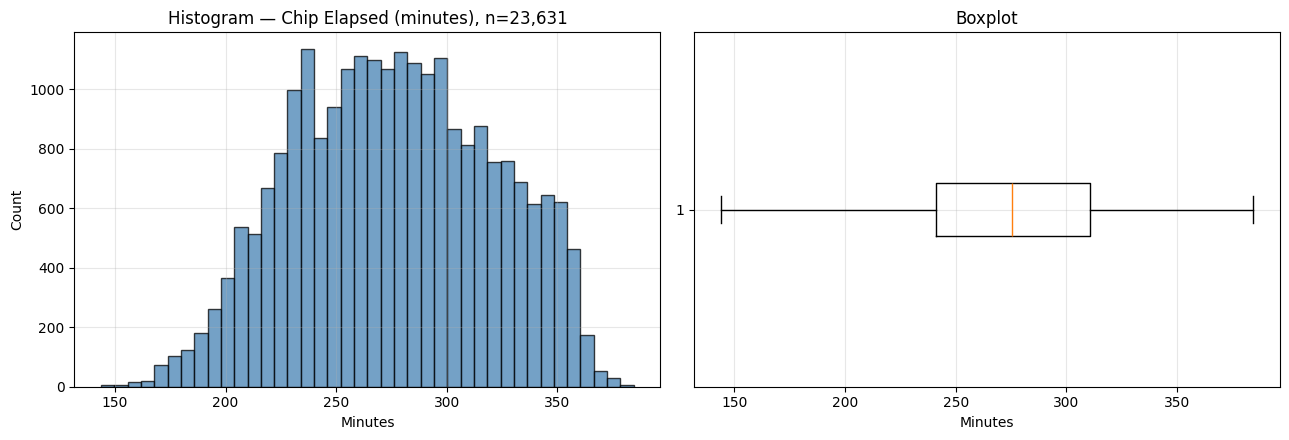

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(data, bins=40, alpha=0.75, color="steelblue", edgecolor="black")
axes[0].set_title(f"Histogram — {TIME_COLUMN} ({TIME_UNIT}), n={n:,}")
axes[0].set_xlabel(TIME_UNIT.capitalize())
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(data, vert=False)
axes[1].set_title("Boxplot")
axes[1].set_xlabel(TIME_UNIT.capitalize())
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 3 — Compare candidates with `Fitter`

The leaderboard is sorted by sum-of-squared-error (lower = closer match
between fitted PDF and histogram). AIC penalizes extra parameters.

In [23]:
f = Fitter(data, distributions=CANDIDATE_DISTRIBUTIONS, timeout=120)
f.fit(progress=False)

leaderboard = f.summary(plot=False, Nbest=len(CANDIDATE_DISTRIBUTIONS))
print(leaderboard)

             sumsquare_error          aic          bic  kl_div  ks_statistic  \
beta                  0.0001 245,551.7473 245,584.0286  0.0160        0.0203   
weibull_min           0.0001 246,332.6490 246,356.8600  0.0297        0.0303   
erlang                0.0001 246,768.2623 246,792.4733  0.0366        0.0344   
gamma                 0.0001 246,768.2668 246,792.4778  0.0366        0.0343   
triang                0.0001 246,911.9275 246,936.1384  0.0634        0.0564   
lognorm               0.0001 246,765.0892 246,789.3002  0.0367        0.0347   
norm                  0.0001 246,763.0869 246,779.2275  0.0367        0.0347   
uniform               0.0008 259,177.4203 259,193.5609  0.6822        0.2070   
expon                 0.0016 278,162.2433 278,178.3840  1.2091        0.3277   

             ks_pvalue  
beta            0.0000  
weibull_min     0.0000  
erlang          0.0000  
gamma           0.0000  
triang          0.0000  
lognorm         0.0000  
norm            0.0000  

In [19]:
print("Best by SSE :", list(f.get_best(method="sumsquare_error").keys())[0])
print("Best by AIC :", list(f.get_best(method="aic").keys())[0])
print("Best by BIC :", list(f.get_best(method="bic").keys())[0])

Best by SSE : beta
Best by AIC : beta
Best by BIC : beta


## Step 4 — Generic goodness-of-fit framework

`gof_tests()` works for **any** continuous SciPy distribution. It runs three
tests, all sharing the same null hypothesis $H_0$: "data come from the fitted
distribution." Large p-values → fail to reject → the distribution is a
defensible choice.

| Test | What it's good at | How we run it |
|---|---|---|
| Kolmogorov–Smirnov | Bulk-of-distribution mismatch | `scipy.stats.kstest` against the fitted CDF |
| Anderson–Darling | Tail mismatch (heavier than KS) | `scipy.stats.goodness_of_fit` with Monte-Carlo p-values — works for any distribution, unlike `scipy.stats.anderson` which only supports a hard-coded list |
| Chi-square | Overall binned counts | Equiprobable bins; `df = k − 1 − (# fitted params)` |

In [20]:
def fit_distribution(data, dist_name):
    """Fit a continuous scipy.stats distribution by name and return both raw
    tuple (positional, for *args) and a name->value dict."""
    dist = getattr(stats, dist_name)
    raw = dist.fit(data)
    arg_names = (dist.shapes.split(", ") if dist.shapes else []) + ["loc", "scale"]
    return dist, dict(zip(arg_names, raw)), raw


def gof_tests(data, dist_name, n_bins=None, n_mc=999, random_state=RANDOM_STATE):
    """Run KS, Anderson-Darling (MC), and Chi-square against the fitted distribution.

    Returns a dict with keys 'distribution', 'params', 'KS', 'AD', 'Chi2'.
    """
    dist, named, raw = fit_distribution(data, dist_name)
    n = len(data)
    n_est = len(raw)  # number of estimated parameters

    # ---- KS ----
    D, p_ks = stats.kstest(data, dist.cdf, args=raw)
    ks = {"stat": float(D), "p": float(p_ks)}

    # ---- Anderson-Darling, Monte Carlo p-value ----
    try:
        gof = stats.goodness_of_fit(
            dist, data, statistic="ad",
            n_mc_samples=n_mc, random_state=random_state,
        )
        ad = {"stat": float(gof.statistic), "p": float(gof.pvalue)}
    except Exception as e:
        ad = {"stat": np.nan, "p": np.nan, "error": str(e)}

    # ---- Chi-square with equiprobable bins ----
    if n_bins is None:
        # Aim for >=5 expected per bin, cap at ~sqrt(n) but no more than 25
        n_bins = max(5, min(int(np.sqrt(n)), 25))
        n_bins = min(n_bins, n // 5)
    edges = dist.ppf(np.linspace(0, 1, n_bins + 1), *raw)
    edges[0]  = -np.inf
    edges[-1] = np.inf
    obs, _ = np.histogram(data, bins=edges)
    exp_   = np.full(n_bins, n / n_bins)
    chi2   = float(np.sum((obs - exp_) ** 2 / exp_))
    df_chi = n_bins - 1 - n_est
    if df_chi <= 0:
        chi = {"stat": chi2, "p": np.nan, "df": df_chi, "n_bins": n_bins,
               "note": "df<=0; reduce # estimated parameters or increase n_bins"}
    else:
        chi = {"stat": chi2, "p": float(1 - stats.chi2.cdf(chi2, df_chi)),
               "df": df_chi, "n_bins": n_bins,
               "observed": obs.tolist(),
               "expected": [round(x, 3) for x in exp_]}

    return {"distribution": dist_name, "params": named, "raw_params": raw,
            "KS": ks, "AD": ad, "Chi2": chi}


def print_gof_report(res, alpha=0.05):
    print(f"Distribution: {res['distribution']}")
    print(f"Fitted params:")
    for k, v in res["params"].items():
        print(f"  {k:>8} = {v:.6f}")
    print()
    print(f"  Goodness-of-fit (alpha = {alpha}):")
    print(f"    KS     stat = {res['KS']['stat']:.4f}  p = {res['KS']['p']:.4f}  -> "
          f"{'fail to reject' if res['KS']['p'] > alpha else 'REJECT'}")
    if not np.isnan(res["AD"]["p"]):
        print(f"    AD     stat = {res['AD']['stat']:.4f}  p = {res['AD']['p']:.4f}  -> "
              f"{'fail to reject' if res['AD']['p'] > alpha else 'REJECT'}")
    chi = res["Chi2"]
    if not np.isnan(chi["p"]):
        print(f"    Chi^2  stat = {chi['stat']:.4f}  df = {chi['df']}  p = {chi['p']:.4f}  -> "
              f"{'fail to reject' if chi['p'] > alpha else 'REJECT'}  ({chi['n_bins']} bins)")
    else:
        print(f"    Chi^2  stat = {chi['stat']:.4f}  ({chi.get('note','')})")

## Step 5 — Run GoF on the leading candidate(s)

By default we test the top distribution by SSE. Override `CHOSEN_DIST` to
test a different one — the rest of the notebook adapts automatically.

> **Large-sample caveat.** With several thousand observations, formal GoF
> tests are very sensitive — they will often reject *every* parametric
> distribution, even the best-fitting one, because they detect tiny
> deviations that don't matter in practice. In that situation, prefer the
> ranked AIC/SSE/KS-statistic from the leaderboard plus the visual checks
> (Step 6) over the test p-values for picking your Simio input distribution.

In [21]:
CHOSEN_DIST = list(f.get_best(method="sumsquare_error").keys())[0]
print(f"Testing distribution: {CHOSEN_DIST}\n")

result = gof_tests(data, CHOSEN_DIST)
print_gof_report(result)

Testing distribution: beta

Distribution: beta
Fitted params:
         a = 3.465782
         b = 2.826410
       loc = 142.942543
     scale = 242.202552

  Goodness-of-fit (alpha = 0.05):
    KS     stat = 0.0203  p = 0.0000  -> REJECT
    AD     stat = 27.2715  p = 0.0010  -> REJECT
    Chi^2  stat = 410.1991  df = 20  p = 0.0000  -> REJECT  (25 bins)


In [22]:
# Also test the next two candidates so you can compare.
ranked = leaderboard.sort_values("sumsquare_error").index.tolist()
runners_up = [d for d in ranked if d != CHOSEN_DIST][:2]

for d in runners_up:
    print("=" * 60)
    print_gof_report(gof_tests(data, d))
    print()

Distribution: weibull_min
Fitted params:
         c = 3.481957
       loc = 137.042230
     scale = 154.822742

  Goodness-of-fit (alpha = 0.05):
    KS     stat = 0.0303  p = 0.0000  -> REJECT
    AD     stat = 48.4148  p = 0.0010  -> REJECT
    Chi^2  stat = 731.7809  df = 21  p = 0.0000  -> REJECT  (25 bins)

Distribution: erlang
Fitted params:
         a = 12406.637234
       loc = -4714.626716
     scale = 0.402262

  Goodness-of-fit (alpha = 0.05):
    KS     stat = 0.0344  p = 0.0000  -> REJECT
    AD     stat = 64.4777  p = 0.0010  -> REJECT
    Chi^2  stat = 1042.7114  df = 21  p = 0.0000  -> REJECT  (25 bins)



## Step 6 — Visual confirmation: PDF overlay, CDF, Q-Q plot

TypeError: _parse_args() takes from 2 to 4 positional arguments but 5 were given

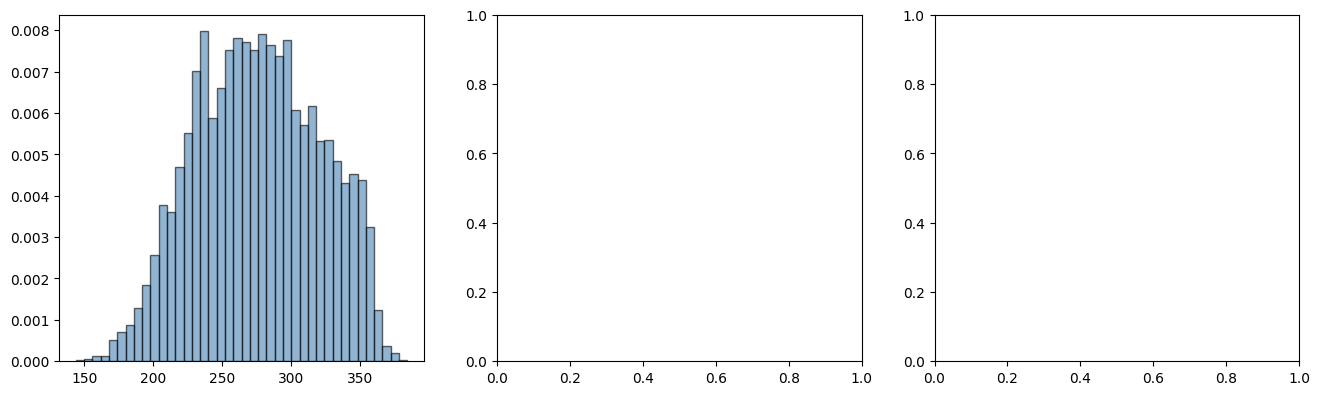

In [29]:
def plot_fit(data, dist_name, raw_params, time_unit=TIME_UNIT):
    dist = getattr(stats, dist_name)
    n = len(data)
    xs = np.linspace(np.min(data), np.max(data), 400)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # PDF overlay
    axes[0].hist(data, bins=40, density=True, alpha=0.6, color="steelblue", edgecolor="black")
    axes[0].plot(xs, dist.pdf(xs, *raw_params), "r-", lw=2, label=f"Fitted {dist_name}")
    axes[0].set_title("PDF overlay")
    axes[0].set_xlabel(time_unit.capitalize())
    axes[0].set_ylabel("Density")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ECDF vs theoretical CDF
    sorted_x = np.sort(data)
    ecdf = np.arange(1, n + 1) / n
    axes[1].step(sorted_x, ecdf, where="post", lw=2, label="Empirical CDF")
    axes[1].plot(sorted_x, dist.cdf(sorted_x, *raw_params), "r-", lw=2, label=f"Fitted {dist_name} CDF")
    axes[1].set_title("CDF comparison (KS test visualization)")
    axes[1].set_xlabel(time_unit.capitalize())
    axes[1].set_ylabel("F(x)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Q-Q plot
    # Generate quantiles from the fitted distribution
    probs = (np.arange(1, n + 1) - 0.5) / n
    theo = dist.ppf(probs, *raw_params)
    axes[2].scatter(theo, sorted_x, s=8, alpha=0.4)
    lims = [min(theo.min(), sorted_x.min()), max(theo.max(), sorted_x.max())]
    axes[2].plot(lims, lims, "r-", lw=2)
    axes[2].set_title(f"Q-Q plot vs {dist_name}")
    axes[2].set_xlabel("Theoretical quantiles")
    axes[2].set_ylabel("Empirical quantiles")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_fit(data, "triang", result["raw_params"])

## Step 7 — Convert the fit to a Simio `Random.*` expression

Simio's parameter conventions don't always match SciPy's. This registry handles
the common cases and emits a ready-to-paste expression. Notable conventions:

- `Random.Lognormal(Mean, StdDev)` — Mean and StdDev are of the **lognormal
  distribution itself**, not the underlying normal (matching Arena's `LOGN`).
- `Random.Weibull(Scale, Shape)` — **scale comes first**.
- `Random.Beta(Shape1, Shape2)` — defined on **[0, 1]**; for a shifted/scaled
  beta we wrap with `Min + (Max - Min) * Random.Beta(...)`.
- `Random.Exponential(Mean)` — Simio uses **mean**, not rate.
- `Random.Erlang(Mean, k)` — Mean = k × scale (SciPy parameterizes by scale).
- A non-zero scipy `loc` becomes a `loc + ...` shift in front of the expression.

In [25]:
def _fmt(x, p=6):
    """Compact float formatter — strips trailing zeros, no scientific notation
    for typical simulation magnitudes."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "NaN"
    s = f"{float(x):.{p}f}"
    if "." in s:
        s = s.rstrip("0").rstrip(".")
    return s if s else "0"


def to_simio(dist_name, params):
    """SciPy parameter dict -> Simio Random.* expression.

    Returns a dict with `expression`, `parameters` (Simio-named), and `notes`.
    """
    p     = params
    loc   = float(p.get("loc", 0.0))
    scale = float(p.get("scale", 1.0))

    def _shift(expr, msg=None):
        if abs(loc) > 1e-12:
            note = msg or f"Non-zero scipy loc shifts the result; '{_fmt(loc)} + ' is prepended."
            return f"{_fmt(loc)} + {expr}", [note]
        return expr, []

    if dist_name == "norm":
        return {
            "parameters": {"Mean": loc, "StdDev": scale},
            "expression": f"Random.Normal({_fmt(loc)}, {_fmt(scale)})",
            "notes": [],
        }

    if dist_name == "expon":
        expr, notes = _shift(f"Random.Exponential({_fmt(scale)})")
        return {"parameters": {"Mean": scale, "Offset": loc},
                "expression": expr, "notes": notes}

    if dist_name == "lognorm":
        s     = float(p["s"])               # = sigma of underlying normal
        mu_n  = float(np.log(scale))        # = mu of underlying normal
        var_n = s * s
        mean_ln = float(np.exp(mu_n + var_n / 2))
        var_ln  = float((np.exp(var_n) - 1) * np.exp(2 * mu_n + var_n))
        std_ln  = float(np.sqrt(var_ln))
        expr, notes = _shift(f"Random.Lognormal({_fmt(mean_ln)}, {_fmt(std_ln)})")
        notes = [
            "Simio Random.Lognormal(Mean, StdDev) takes the mean and std of the LOGNORMAL itself (Arena convention).",
            f"Underlying normal:  mu = {_fmt(mu_n)},  sigma = {_fmt(s)}.",
        ] + notes
        return {"parameters": {"Mean": mean_ln, "StdDev": std_ln, "Offset": loc},
                "expression": expr, "notes": notes}

    if dist_name == "gamma":
        a = float(p["a"])
        expr, notes = _shift(f"Random.Gamma({_fmt(a)}, {_fmt(scale)})")
        return {"parameters": {"Shape": a, "Scale": scale, "Offset": loc},
                "expression": expr, "notes": notes}

    if dist_name == "erlang":
        k_int = int(round(float(p["a"])))
        mean  = k_int * scale
        expr, notes = _shift(f"Random.Erlang({_fmt(mean)}, {k_int})")
        notes = ["Simio Random.Erlang(Mean, k); Mean = k * scale_scipy."] + notes
        return {"parameters": {"Mean": mean, "k": k_int, "Offset": loc},
                "expression": expr, "notes": notes}

    if dist_name == "weibull_min":
        c = float(p["c"])
        expr, notes = _shift(f"Random.Weibull({_fmt(scale)}, {_fmt(c)})")
        notes = ["Simio Random.Weibull(Scale, Shape) -- scale comes first."] + notes
        return {"parameters": {"Scale": scale, "Shape": c, "Offset": loc},
                "expression": expr, "notes": notes}

    if dist_name == "beta":
        a, b = float(p["a"]), float(p["b"])
        if abs(loc) < 1e-12 and abs(scale - 1.0) < 1e-12:
            expr  = f"Random.Beta({_fmt(a)}, {_fmt(b)})"
            notes = []
        else:
            expr  = f"{_fmt(loc)} + {_fmt(scale)} * Random.Beta({_fmt(a)}, {_fmt(b)})"
            notes = ["Simio Random.Beta is on [0, 1]; the wrapper rescales it to [Min, Max]."]
        return {"parameters": {"Shape1": a, "Shape2": b, "Min": loc, "Max": loc + scale},
                "expression": expr, "notes": notes}

    if dist_name == "triang":
        c = float(p["c"])
        mn   = loc
        mx   = loc + scale
        mode = loc + c * scale
        return {"parameters": {"Min": mn, "Mode": mode, "Max": mx},
                "expression": f"Random.Triangular({_fmt(mn)}, {_fmt(mode)}, {_fmt(mx)})",
                "notes": []}

    if dist_name == "uniform":
        return {"parameters": {"Min": loc, "Max": loc + scale},
                "expression": f"Random.Uniform({_fmt(loc)}, {_fmt(loc + scale)})",
                "notes": []}

    if dist_name == "invgamma":   # = Pearson Type V
        a = float(p["a"])
        expr, notes = _shift(f"Random.Pearson5({_fmt(a)}, {_fmt(scale)})")
        notes = ["Pearson Type V == scipy.stats.invgamma."] + notes
        return {"parameters": {"Shape": a, "Scale": scale, "Offset": loc},
                "expression": expr, "notes": notes}

    if dist_name == "betaprime":  # ~ Pearson Type VI scaled
        a, b = float(p["a"]), float(p["b"])
        expr, notes = _shift(f"Random.Pearson6({_fmt(a)}, {_fmt(b)}, {_fmt(scale)})")
        notes = ["Pearson Type VI ~ scipy.stats.betaprime (scaled)."] + notes
        return {"parameters": {"Shape1": a, "Shape2": b, "Scale": scale, "Offset": loc},
                "expression": expr, "notes": notes}

    # Fallback for distributions Simio doesn't have a direct match for
    return {
        "parameters": dict(p),
        "expression": (f"# {dist_name}: no direct Simio Random.* equivalent. "
                       f"Build a Continuous or Empirical distribution from the CDF."),
        "notes": [f"{dist_name} has no direct Simio function. "
                  f"Consider tabulating the CDF and using Random.Continuous(...)."],
    }


def print_simio(dist_name, named_params):
    out = to_simio(dist_name, named_params)
    print(f"Distribution: {dist_name}")
    print(f"Simio parameters:")
    for k, v in out["parameters"].items():
        print(f"  {k:>8} = {v:.6f}" if isinstance(v, (int, float)) else f"  {k:>8} = {v}")
    print()
    print(f"Simio expression (paste into Simio):")
    print(f"    {out['expression']}")
    if out["notes"]:
        print()
        print("Notes:")
        for n in out["notes"]:
            print(f"  - {n}")
    return out

In [26]:
simio = print_simio(CHOSEN_DIST, result["params"])

Distribution: beta
Simio parameters:
    Shape1 = 3.465782
    Shape2 = 2.826410
       Min = 142.942543
       Max = 385.145096

Simio expression (paste into Simio):
    142.942543 + 242.202552 * Random.Beta(3.465782, 2.82641)

Notes:
  - Simio Random.Beta is on [0, 1]; the wrapper rescales it to [Min, Max].


## Step 8 — Final report

A single block summarizing everything you need for the Simio model.

In [ ]:
def final_report(data, gof_result, simio_result, time_unit, label):
    n = len(data)
    print("=" * 70)
    print(f"  Big Sur Marathon — Distribution-fitting report")
    print(f"  Subset: {label}")
    print("=" * 70)
    print(f"  n         : {n:,}")
    print(f"  unit      : {time_unit}")
    print(f"  empirical : mean = {np.mean(data):.4f}, "
          f"std = {np.std(data, ddof=1):.4f}, "
          f"min = {np.min(data):.4f}, max = {np.max(data):.4f}")
    print(f"  empirical : skew = {stats.skew(data):.4f}, "
          f"excess kurtosis = {stats.kurtosis(data):.4f}")
    print()
    print(f"  Chosen distribution : {gof_result['distribution']}")
    print(f"  SciPy parameters    :")
    for k, v in gof_result["params"].items():
        print(f"     {k:>10} = {v:.6f}")
    print()
    print(f"  Goodness of fit (alpha = 0.05):")
    ks = gof_result["KS"]
    print(f"    KS    stat = {ks['stat']:.4f}   p = {ks['p']:.4f}")
    ad = gof_result["AD"]
    if not np.isnan(ad["p"]):
        print(f"    AD    stat = {ad['stat']:.4f}   p = {ad['p']:.4f}")
    chi = gof_result["Chi2"]
    if not np.isnan(chi["p"]):
        print(f"    Chi^2 stat = {chi['stat']:.4f}   df = {chi['df']}   p = {chi['p']:.4f}")
    print()
    print(f"  Simio parameters (named):")
    for k, v in simio_result["parameters"].items():
        if isinstance(v, (int, float)):
            print(f"     {k:>10} = {v:.6f}")
        else:
            print(f"     {k:>10} = {v}")
    print()
    print(f"  >>> Simio expression <<<")
    print(f"     {simio_result['expression']}")
    if simio_result["notes"]:
        print()
        print("  Notes:")
        for n in simio_result["notes"]:
            print(f"    - {n}")
    print("=" * 70)


final_report(data, result, simio, TIME_UNIT, label)

### What to do with the expression

In Simio:

1. Open your model.
2. Wherever you have a delay, interarrival time, or other random property,
   paste the expression above.
3. If the property is meant to be in **seconds** (or hours), make sure the
   `TIME_UNIT` configuration above matches — re-run the notebook if not.

### How to fit a different slice

- A different year: set `YEAR_FILTER = 2018` (or any year in the data).
- All years pooled: set `YEAR_FILTER = None`.
- Only women: set `GENDER_FILTER = "F"`.
- A specific age band: set `AGE_RANGE = (40, 49)`.
- Test a different distribution: set `CHOSEN_DIST = "lognorm"` (or any name
  in `CANDIDATE_DISTRIBUTIONS`) before re-running Step 5.

In [24]:
# For each candidate, what fraction of samples falls outside the actual data range?
from scipy import stats
data_min, data_max = data.min(), data.max()

for name, params in [("norm", stats.norm.fit(data)),
                     ("lognorm", stats.lognorm.fit(data)),
                     ("gamma", stats.gamma.fit(data))]:
    dist = getattr(stats, name)
    p_low  = dist.cdf(data_min, *params)
    p_high = 1 - dist.cdf(data_max, *params)
    print(f"{name:10s}  P(below min) = {p_low:.3%}   P(above max) = {p_high:.3%}")

norm        P(below min) = 0.157%   P(above max) = 0.777%
lognorm     P(below min) = 0.157%   P(above max) = 0.777%
gamma       P(below min) = 0.145%   P(above max) = 0.808%
